In [54]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

In [55]:
# Load the dataset
df = pd.read_csv('Data/Reviews.csv')
df.head()


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [56]:
#Keeping only the required columns for analysis.
df = df[['Score', 'Summary', 'Text']]

In [57]:
#Checking for null values in the dataset.
df.isnull().sum()

Score       0
Summary    27
Text        0
dtype: int64

In [58]:
#Dropping the null values from the dataset.
df = df.dropna()
df = df.sample(50000, random_state=42)

In [59]:
df.isnull().sum()
#Checking if the null values are dropped or not.

Score      0
Summary    0
Text       0
dtype: int64

In [60]:
#Checking the shape of the dataset after dropping null values.
df.shape

(50000, 3)

In [61]:
#Creating a new column 'Sentiment' based on the 'Score' column.
def sentiment_label(score):
    if score >= 4:
        return 'Positive'
    else:
        return 'Negative'

df['Sentiment'] = df['Score'].apply(sentiment_label)




In [62]:
df = df[df['Text'].str.len() > 20]

In [63]:
#Counting the number of positive, negative and neutral reviews .
df['Sentiment'].value_counts()

Sentiment
Positive    39142
Negative    10857
Name: count, dtype: int64

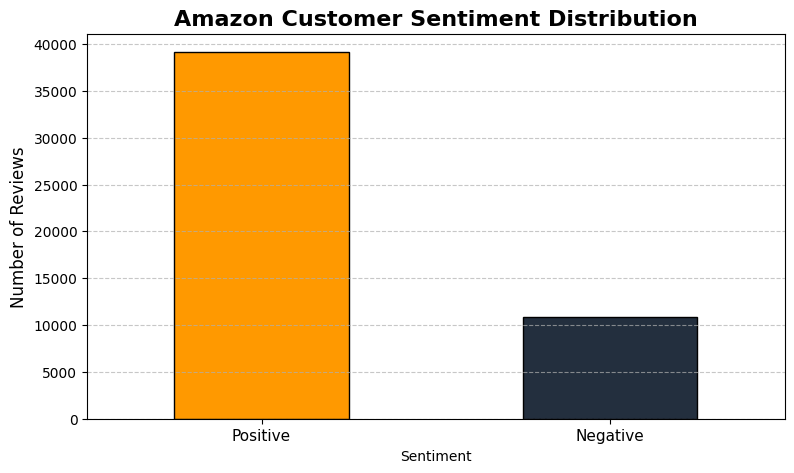

In [64]:
#Visualizing the distribution of sentiments in the dataset.
plt.figure(figsize=(9,5))

df['Sentiment'].value_counts().plot(
    kind='bar',
    color=['#FF9900', '#232F3E',],
    edgecolor='black'
)

plt.title(
    "Amazon Customer Sentiment Distribution",
    fontsize=16,
    fontweight='bold'
)

plt.ylabel("Number of Reviews", fontsize=12)

plt.xticks(rotation=0, fontsize=11)

plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.7
)

plt.show()

In [65]:
#NLP LIBRARIES FOR TEXT PREPROCESSING
import re
import nltk

from nltk.corpus import stopwords

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/rathodomkar/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [66]:
from nltk.stem import PorterStemmer

stemmer = PorterStemmer()

In [67]:
#Creating a set of stop words for text preprocessing.
stop_words = set(stopwords.words('english'))

In [68]:
#Function to clean the text data by removing special characters, numbers, and stop words.
def clean_text(text):
    
    # convert to lowercase
    text = text.lower()
    
    # remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    # remove extra spaces
    text = text.strip()
    
    # remove stopwords
    words = text.split()
    
    filtered_words = [
        word for word in words
        if word not in stop_words
    ]
    
    return " ".join(filtered_words)

In [69]:
#Applying the clean_text function to the 'Text' column and creating a new column 'Cleaned_Text'.
df['Cleaned_Text'] = df['Text'].apply(clean_text)

In [70]:
#Processed text data after cleaning.
df[['Text', 'Cleaned_Text']].head()

,Text,Cleaned_Text
41434,These are actually very tasty. Pure potatoes ...,actually tasty pure potatoes great texture nas...
209481,I realize that taste is a matter of personal p...,realize taste matter personal preference food ...
247306,This is one of my Favorite cup of soup choices...,one favorite cup soup choices never carried st...
80089,If you like the classic taste of a good margar...,like classic taste good margarita likely youll...
218580,I was willing to give this a chance even after...,willing give chance even reading scathing revi...


In [71]:
#Preparing features and labels for model training.
X = df['Cleaned_Text']
y = df['Sentiment'] 

In [72]:
#As machine learning models cannot work with text data directly, we need to convert the text data into numerical features using TF-IDF vectorization.
vectorizer = TfidfVectorizer(max_features=10000,
                             ngram_range=(1,2)
                             )
X_vectorized = vectorizer.fit_transform(X)                             

In [73]:
#Now we have the features and labels ready, we can split the data into training and testing sets.
X_train, X_test, y_train, y_test = train_test_split(
    X_vectorized,
    y,
    test_size=0.2,
    random_state=42
)   

In [88]:
#Now we train a logistic regression model on the training data.
from sklearn.linear_model import LogisticRegression

# Adding 'balanced' automatically penalizes the model heavily 
# every time it misclassifies a minority class (Negative review)
model = LogisticRegression(class_weight='balanced')
model.fit(X_train, y_train)


LogisticRegression(class_weight='balanced')

In [89]:
#Making predictions on the test set.
y_pred = model.predict(X_test)

In [90]:
#Checking the accuracy of the model.
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

Accuracy: 0.86


================ MODEL PERFORMANCE EVALUATION ================

              precision    recall  f1-score   support

    Negative      0.643     0.843     0.729      2183
    Positive      0.952     0.869     0.909      7817

    accuracy                          0.863     10000
   macro avg      0.797     0.856     0.819     10000
weighted avg      0.884     0.863     0.869     10000




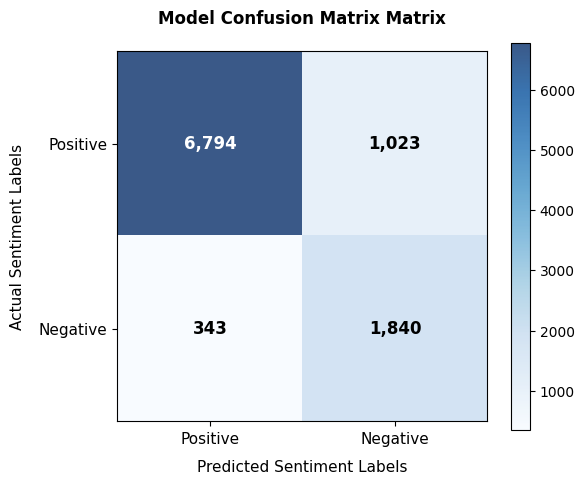

In [101]:
#Checking all the parameters of the model.
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

# 1. Clear text classification summary report
print("================ MODEL PERFORMANCE EVALUATION ================\n")
print(classification_report(y_test, y_pred, digits=3))
print("==============================================================\n")

# 2. Extract standard raw Confusion Matrix arrays
labels = ['Positive',  'Negative']
cm = confusion_matrix(y_test, y_pred, labels=labels)

# 3. Plot clear structural grid using native baseline Matplotlib
fig, ax = plt.subplots(figsize=(6, 5))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# Render the grid box layout
cax = ax.matshow(cm, cmap=plt.cm.Blues, alpha=0.8)
fig.colorbar(cax)

# Draw labels onto coordinates explicitly
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, fontsize=11)
ax.set_yticklabels(labels, fontsize=11)

# Add matrix count data directly inside the blocks
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(x=j, y=i, s=f"{cm[i, j]:,}", 
                va='center', ha='center', 
                size=12, weight='bold',
                color='white' if cm[i, j] > (cm.max() / 2) else 'black')

plt.title('Model Confusion Matrix Matrix', fontsize=12, pad=20, weight='bold')
plt.ylabel('Actual Sentiment Labels', fontsize=11, labelpad=10)
plt.xlabel('Predicted Sentiment Labels', fontsize=11, labelpad=10)
ax.xaxis.set_label_position('bottom')
ax.xaxis.tick_bottom()

plt.tight_layout()
plt.show()



In [102]:
#Installing wordcloud library for visualizing the most common words in positive and negative reviews.
%pip install wordcloud

You should consider upgrading via the '/Users/rathodomkar/Downloads/Projects/Pinnacle labs - Sentiment-Analytics-Dashboard/venv/bin/python -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [103]:
#Visualizing the most common words in positive and negative reviews using wordcloud.
from collections import Counter
from wordcloud import WordCloud

In [104]:
#Separating positive and negative reviews for visualization.
positive_reviews = df[df['Sentiment'] == 'Positive']['Cleaned_Text']
negative_reviews = df[df['Sentiment'] == 'Negative']['Cleaned_Text']

In [105]:
#Combining all positive and negative reviews into a single string for wordcloud generation.
positive_text = " ".join(positive_reviews)  
negative_text = " ".join(negative_reviews)  

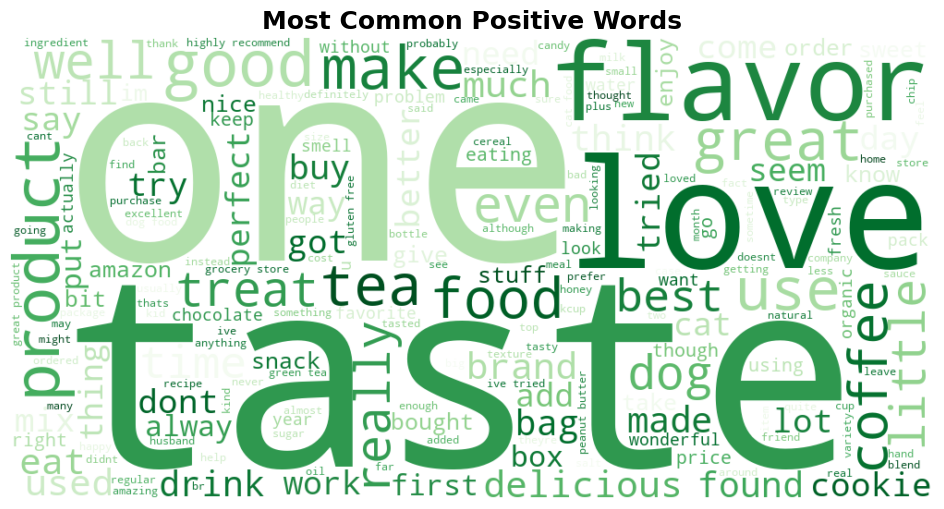

In [106]:
#Generating wordcloud for positive reviews.
wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white',
    colormap='Greens'
).generate(positive_text)

plt.figure(figsize=(12,6))

plt.imshow(wordcloud, interpolation='bilinear')

plt.axis('off')

plt.title(
    "Most Common Positive Words",
    fontsize=18,
    fontweight='bold'
)

plt.show()

In [107]:
#Custom stop words to remove from the negative wordcloud visualization.
negative_stopwords = {
    'taste',
    'tea',
    'food',
    'product',
    'coffee',
    'dog',
    'flavor',
    'buy',
    'order',
    'amazon',
    'eat'
    'ive'
    'love'
    'good'
    ' br',
    'like',
    'would',
    'one',
    'product',
    'good',
    'food',
    'coffee',
    'taste',
    'flavor'
}

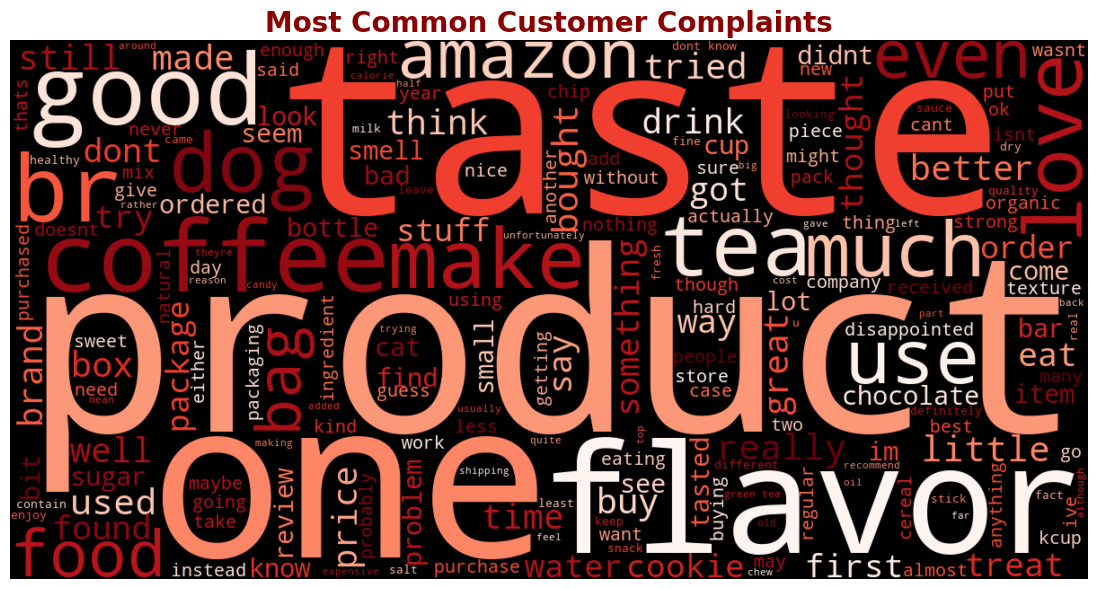

In [108]:
#Generating wordcloud for negative reviews.
wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color='black',
    colormap='Reds',
    contour_color='white',
    contour_width=1
).generate(negative_text)

plt.figure(figsize=(14,7))

plt.imshow(wordcloud, interpolation='bilinear')

plt.axis('off')

plt.title(
    "Most Common Customer Complaints",
    fontsize=20,
    fontweight='bold',
    color='darkred'
)

plt.show()

In [109]:
remove_words = {
    'br',
    'like',
    'would',
    'one',
    'product',
    'good',
    'food',
    'coffee',
    'taste',
    'flavor',
    'dont',
    'great',
    'get',
    'really',
    'much',
    'even',
    'buy',
    'im',
    'little',
    'tea',
    'better'
}

In [110]:
#Top complaint words in negative reviews by counting the frequency of words in the negative reviews and displaying the top 10 most common words.
negative_words = [
    word for word in negative_text.split()
    if word not in remove_words
]

common_negative_words = Counter(
    negative_words
).most_common(10)

common_negative_words

[('time', 1540),
 ('amazon', 1507),
 ('first', 1504),
 ('tried', 1497),
 ('box', 1471),
 ('also', 1470),
 ('try', 1463),
 ('dog', 1453),
 ('bought', 1402),
 ('eat', 1361)]